##Visualize GELECTRA emotion results (titles)

In [170]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

### Load data

In [171]:
path="/Users/gretawette/Documents/Thesis/04_SentimentAnalysis/outputs/emotion_mainstream_resultsv2.csv"
df = pd.read_csv(path, encoding="utf-8", low_memory=False)
df.columns = df.columns.astype(str).str.replace("\ufeff", "", regex=False).str.strip()

# Drop IRRELEVANT framing rows
df = df[df["category"] != "IRRELEVANT"].copy()



In [172]:
df = df[df["source"] != "Tagesschau"].copy()

In [173]:
df

,hit_id,row_id,source,Title,hit_text,context_idx,count_hits,count_unique_entities,context_window,model,...,raw_response_json,emotion_anger,emotion_fear,emotion_disgust,emotion_sadness,emotion_joy,emotion_enthusiasm,emotion_pride,emotion_hope,emotion_dominant
0,d844fe7dbcb4b28a,1,Antispiegel,Bereitet der Westen die Entmachtung oder sogar...,Politico,1,1,1,"Er hat es geschafft, seine Leute überall zu pl...",gpt-5-mini,...,"{""id"": ""resp_0e3ba66f85f590500069c463579898819...",0.941640,0.222315,0.067098,0.371479,0.038148,0.042348,0.085279,0.061830,anger
1,f785774b2205e418,4,Antispiegel,Fordert Russland wirklich die Vernichtung alle...,Bild-Zeitung,1,1,1,Viele haben Reitschuster aus der Corona-Zeit j...,gpt-5-mini,...,"{""id"": ""resp_05d159969059d7ad0069c4635784cc819...",0.984082,0.148221,0.508094,0.405711,0.017550,0.021857,0.025569,0.013587,anger
2,8beba1b1263837c4,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,Spiegel,1,1,1,Der Spiegel macht mal wieder Berichterstattung...,gpt-5-mini,...,"{""id"": ""resp_084a85555116e7270069c4635799bc819...",0.989845,0.144035,0.222804,0.305253,0.010692,0.008305,0.010875,0.008144,anger
3,db28e215f2d3989d,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,Spiegel,2,1,1,Das NABU ist das vielleicht wichtigste Instrum...,gpt-5-mini,...,"{""id"": ""resp_067c239f074dd8230069c46357985c819...",0.596646,0.065551,0.020142,0.345275,0.045382,0.043510,0.170900,0.061692,anger
4,387a8dd7ac2cedde,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,Spiegel,3,4,1,"Ich denke, die Antwort liegt auf der Hand. Mär...",gpt-5-mini,...,"{""id"": ""resp_0f30c6857a242fb20069c463578cd0819...",0.829127,0.124565,0.060345,0.369028,0.091420,0.033177,0.123205,0.047025,anger
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7598,f7c113069a27ebcf,14104,Deutschlandkurier,Bundestags-Debatte zu Paragraph 188: „Freiheit...,Süddeutsche Zeitung,1,1,1,Ist Spahn schizophren? Zusätzlich politische B...,gpt-5-mini,...,"{""id"": ""resp_0bad9301a22fe6230069c470ea0c88819...",0.655117,0.065553,0.015301,0.222610,0.032010,0.027019,0.092376,0.041669,anger
7599,863c351230704a88,14106,Deutschlandkurier,Neues aus dem Clownsland: Jens „Umfaller“ Spah...,Staatsfunk,1,1,1,Die Sozis haben gleich zu Koalitionsbeginn abe...,gpt-5-mini,...,"{""id"": ""resp_01adbdad332032700069c470ea20c4819...",0.979781,0.182384,0.078540,0.129461,0.028087,0.053517,0.048590,0.105895,anger
7600,dc232a562d393ed3,14106,Deutschlandkurier,Neues aus dem Clownsland: Jens „Umfaller“ Spah...,Staatsfunk,2,1,1,Und trotzdem scheint er irgendwie auf der Absc...,gpt-5-mini,...,"{""id"": ""resp_09f4e00648721dea0069c470ea9704819...",0.950707,0.302222,0.056444,0.313621,0.023653,0.041177,0.050062,0.082457,anger
7601,ded053af8b6b279a,14111,Deutschlandkurier,Vom System durch die 188-Mangel gedreht: Rentn...,Spiegel,1,1,1,Im Juni 2025 wurde Niehoff vom Amtsgericht Haß...,gpt-5-mini,...,"{""id"": ""resp_021d81c122ec7e280069c470eb1b0c819...",0.983040,0.306496,0.485398,0.544901,0.010525,0.008980,0.010680,0.007757,anger


In [174]:
OUTLET_COL = "source" if "source" in df.columns else None
if OUTLET_COL is None:
    for c in df.columns:
        if c.lower() in ("source", "outlet", "datasource"):
            OUTLET_COL = c
            break
if OUTLET_COL is None:
    raise KeyError(f"No outlet column found. Columns: {list(df.columns)}")

EMOTION_COLS = [
    "emotion_anger",
    "emotion_fear",
    "emotion_disgust",
    "emotion_sadness",
    "emotion_joy",
    "emotion_enthusiasm",
    "emotion_pride",
    "emotion_hope",
]
EMOTION_SHORT = [c.replace("emotion_", "") for c in EMOTION_COLS]

for c in EMOTION_COLS:
    if c not in df.columns:
        raise KeyError(f"Missing {c}; got {list(df.columns)}")


print(f"Rows: {len(df):,}")
print(f"Outlets ({OUTLET_COL}): {df[OUTLET_COL].nunique()}")
df[[OUTLET_COL] + EMOTION_COLS[:3]].head()

Rows: 7,425
Outlets (source): 6


,source,emotion_anger,emotion_fear,emotion_disgust
0,Antispiegel,0.941640,0.222315,0.067098
1,Antispiegel,0.984082,0.148221,0.508094
2,Antispiegel,0.989845,0.144035,0.222804
3,Antispiegel,0.596646,0.065551,0.020142
4,Antispiegel,0.829127,0.124565,0.060345


In [175]:
# Emotion colours (aligned with inspiration notebook)
emotion_colors = {
    "anger": "#e66101",
    "fear": "#5e3c99",
    "disgust": "#1b7837",
    "sadness": "#2166ac",
    "joy": "#fdb863",
    "enthusiasm": "#b2abd2",
    "pride": "#d01c8b",
    "hope": "#80cdc1",
}

# Distinct colours for outlets (Tab10 + extras if needed)
outlets_sorted = sorted(df[OUTLET_COL].dropna().unique())
pal = sns.color_palette("tab10", n_colors=max(10, len(outlets_sorted)))
outlet_colors = {o: pal[i % len(pal)] for i, o in enumerate(outlets_sorted)}

<hr style="opacity:0.35">

### Summary statistics

In [176]:
summary_stats = df[EMOTION_COLS].describe().T
summary_stats.index = EMOTION_SHORT
summary_stats = summary_stats.rename(
    columns={
        "count": "N",
        "mean": "Mean",
        "std": "Std",
        "min": "Min",
        "50%": "Median",
        "max": "Max",
    }
).round(4)
summary_stats

,N,Mean,Std,Min,25%,Median,75%,Max
anger,7425.0,0.7776,0.2167,0.0268,0.6669,0.8580,0.9470,0.9932
fear,7425.0,0.2193,0.1916,0.0046,0.0779,0.1528,0.2992,0.9346
disgust,7425.0,0.0784,0.1254,0.0007,0.0126,0.0342,0.0843,0.9421
sadness,7425.0,0.2653,0.2011,0.0036,0.1164,0.2104,0.3608,0.9489
joy,7425.0,0.0481,0.0764,0.0041,0.0175,0.0273,0.0469,0.9048
enthusiasm,7425.0,0.0517,0.0603,0.0033,0.0186,0.0323,0.0593,0.7995
pride,7425.0,0.0962,0.1161,0.0028,0.0257,0.0550,0.1179,0.9297
hope,7425.0,0.1029,0.1181,0.0046,0.0321,0.0607,0.1227,0.9349


In [177]:
total_titles = len(df)
outlet_summary = (
    df.groupby(OUTLET_COL, observed=True)
    .size()
    .reset_index(name="N")
    .sort_values("N", ascending=False)
)
outlet_summary["Share (%)"] = (outlet_summary["N"] / total_titles * 100).round(2)
outlet_summary

,source,N,Share (%)
5,Tichys_Einblick,2233,30.07
3,Nius,1984,26.72
4,RT_de,1831,24.66
0,Antispiegel,532,7.16
1,Compact,465,6.26
2,Deutschlandkurier,380,5.12


In [178]:
print("Dominant emotion (full corpus):")
print(df["emotion_dominant"].value_counts(normalize=True).round(4) * 100)

print("\nDominant emotion by outlet (share within each outlet, %):")
dominant_share = pd.crosstab(
    df[OUTLET_COL], df["emotion_dominant"], normalize="index"
).round(4) * 100
display(dominant_share)

Dominant emotion (full corpus):
emotion_dominant
anger         90.91
sadness        3.21
pride          2.76
hope           1.98
joy            0.62
fear           0.48
disgust        0.03
enthusiasm     0.01
Name: proportion, dtype: float64

Dominant emotion by outlet (share within each outlet, %):


emotion_dominant,anger,disgust,enthusiasm,fear,hope,joy,pride,sadness
source,,,,,,,,
Antispiegel,95.30,0.0,0.00,0.19,1.13,0.00,2.26,1.13
Compact,86.45,0.0,0.22,0.65,1.08,0.65,6.02,4.95
Deutschlandkurier,91.05,0.0,0.00,0.26,4.74,0.53,1.84,1.58
Nius,89.16,0.1,0.00,0.55,1.56,1.21,2.87,4.54
RT_de,89.51,0.0,0.00,0.76,3.44,0.27,1.97,4.04
Tichys_Einblick,93.46,0.0,0.00,0.27,1.07,0.54,2.91,1.75


<hr style="opacity:0.35">

### Visualizations — corpus-wide mean probabilities

Same idea as inspiration: **average softmax score per title**, then **mean across all titles**.

### Dominant-emotion shares by outlet (%)

## Emotion vs. Framing category & hits

In [179]:


# Filter emotion probability columns (assume columns starting with 'emotion_' and not 'emotion_dominant')
emotion_prob_cols = [col for col in df.columns if col.startswith("emotion_") and col not in ["emotion_dominant"]]

# Compute mean emotion probabilities per framing category
framing_emotion_means = (
    df.groupby("category")[emotion_prob_cols]
    .mean()
    .reset_index()
    .rename_axis(None, axis=1)
)

# Sort framing categories by count, if desired (optional)
# framing_order = df["framing"].value_counts().index
# framing_emotion_means["framing"] = pd.Categorical(framing_emotion_means["framing"], categories=framing_order, ordered=True)
# framing_emotion_means = framing_emotion_means.sort_values("framing")

display(framing_emotion_means)


,category,emotion_anger,emotion_fear,emotion_disgust,emotion_sadness,emotion_joy,emotion_enthusiasm,emotion_pride,emotion_hope
0,DISINFORMATION/FALSCHDARSTELLUNG,0.885084,0.194844,0.111669,0.278704,0.033613,0.038627,0.074730,0.059396
1,NEUTRAL,0.712775,0.217520,0.058728,0.252287,0.052098,0.053412,0.099704,0.119149
2,POSITIONS-/PARTEILICHKEITS-BIAS,0.864669,0.230256,0.103753,0.276033,0.046236,0.058105,0.103069,0.093910
3,VERSAGEN/INKOMPETENZ,0.834688,0.204089,0.094357,0.288913,0.041263,0.042858,0.089629,0.075805
4,VERZERRUNG/MANIPULATION,0.870601,0.225065,0.108446,0.292243,0.041814,0.043842,0.082968,0.072458


### Example: distribution of **anger** and **fear** by outlet (boxplot)

### Export summary tables (optional)

Saved next to figures for use in the thesis.

### Heatmaps: mean emotion per outlet × framing category

One heatmap each for **anger**, **fear**, and **sadness** — rows = framing categories, columns = outlets. Color scale diverges from the corpus-wide macro-mean of each emotion so red = above average, blue = below average.

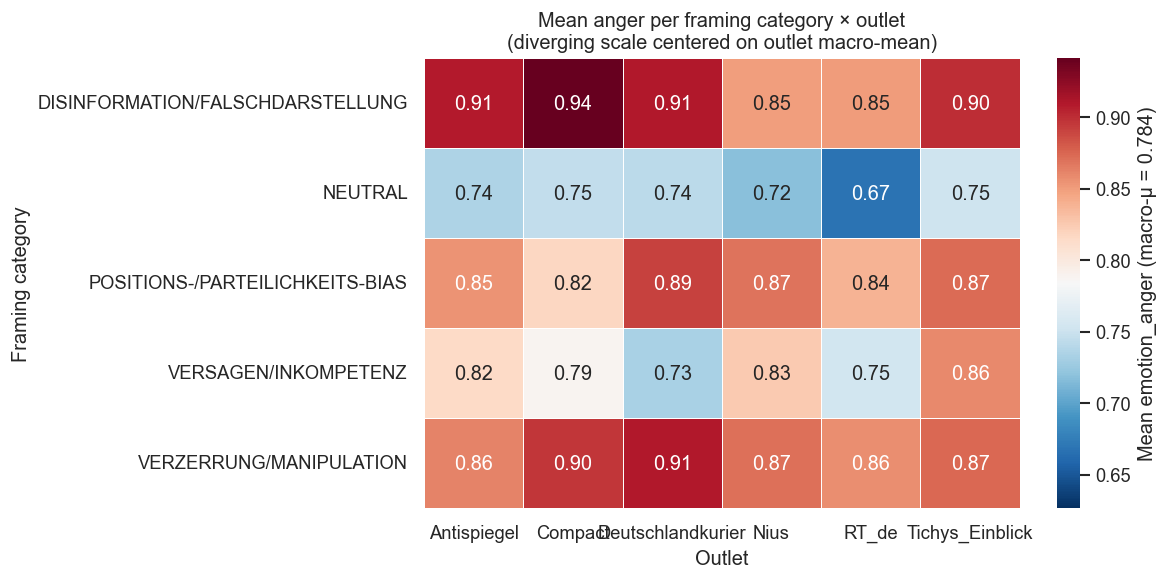

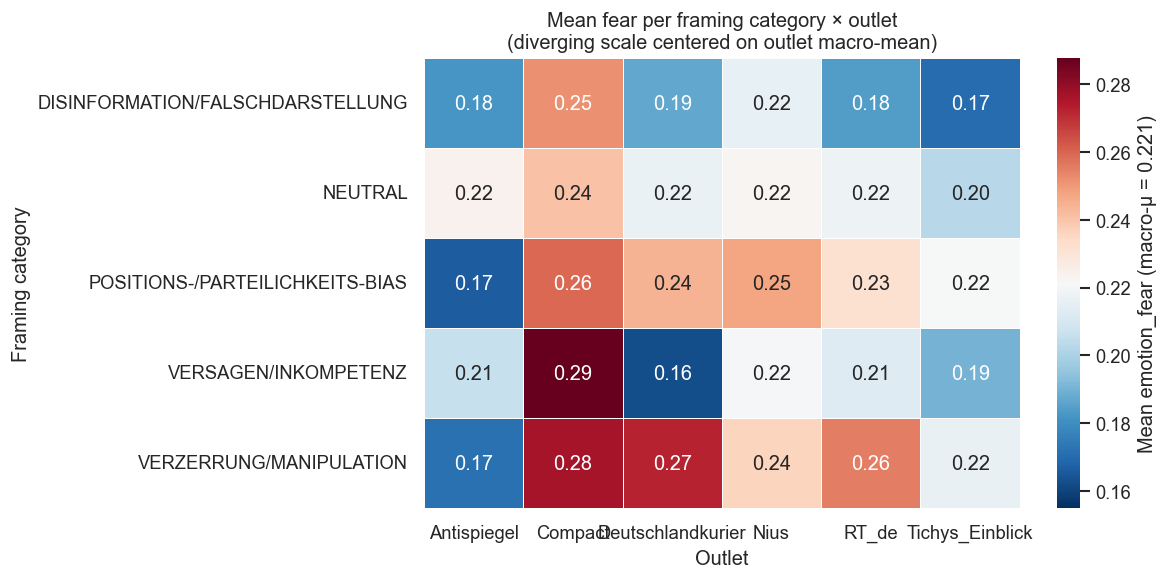

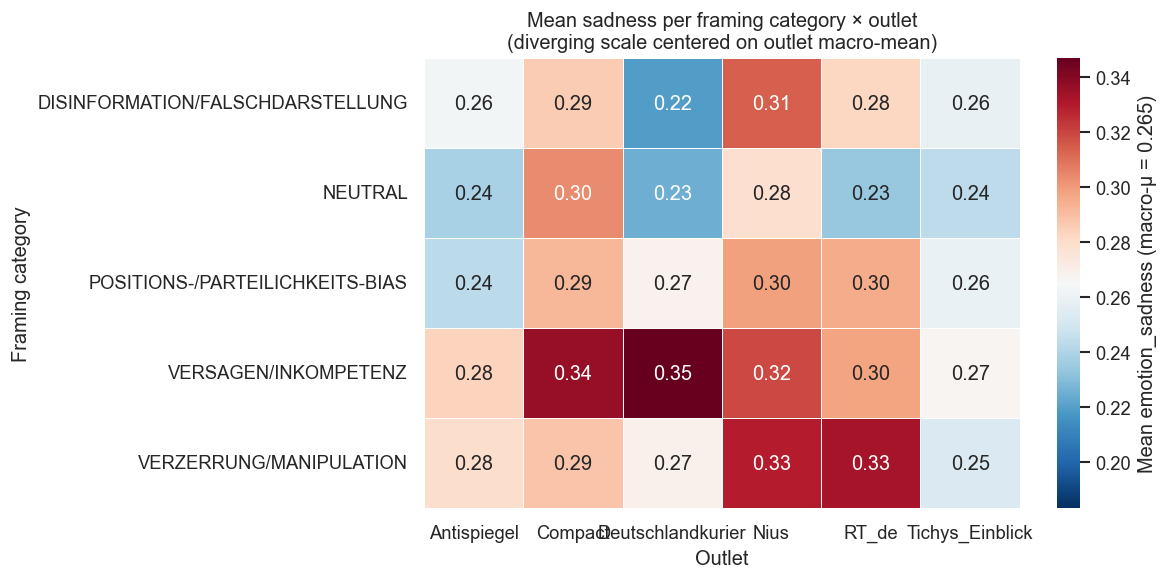

In [180]:
for emotion in ["emotion_anger", "emotion_fear", "emotion_sadness"]:
    # pivot: rows = framing category, columns = outlet
    pivot = (
        df.dropna(subset=["category", OUTLET_COL, emotion])
        .groupby(["category", OUTLET_COL])[emotion]
        .mean()
        .unstack(OUTLET_COL)
    )
    pivot = pivot.reindex(sorted(pivot.index))   # alphabetical frame order

    # macro-mean: average of per-outlet means (corrects for outlet size imbalance)
    macro_mean = float(df.groupby(OUTLET_COL)[emotion].mean().mean())
    spread = max(float((pivot - macro_mean).abs().max().max()), 1e-6)

    fig, ax = plt.subplots(figsize=(max(10, 0.9 * pivot.shape[1]),
                                    max(5, 0.38 * pivot.shape[0])))
    sns.heatmap(
        pivot, ax=ax,
        annot=True, fmt=".2f",
        cmap="RdBu_r",
        center=macro_mean,
        vmin=macro_mean - spread,
        vmax=macro_mean + spread,
        linewidths=0.4,
        cbar_kws={"label": f"Mean {emotion} (macro-μ = {macro_mean:.3f})"},
    )
    ax.set_title(f"Mean {emotion.replace('emotion_', '')} per framing category × outlet"
                 f"\n(diverging scale centered on outlet macro-mean)")
    ax.set_xlabel("Outlet")
    ax.set_ylabel("Framing category")
    plt.tight_layout()
    plt.show()

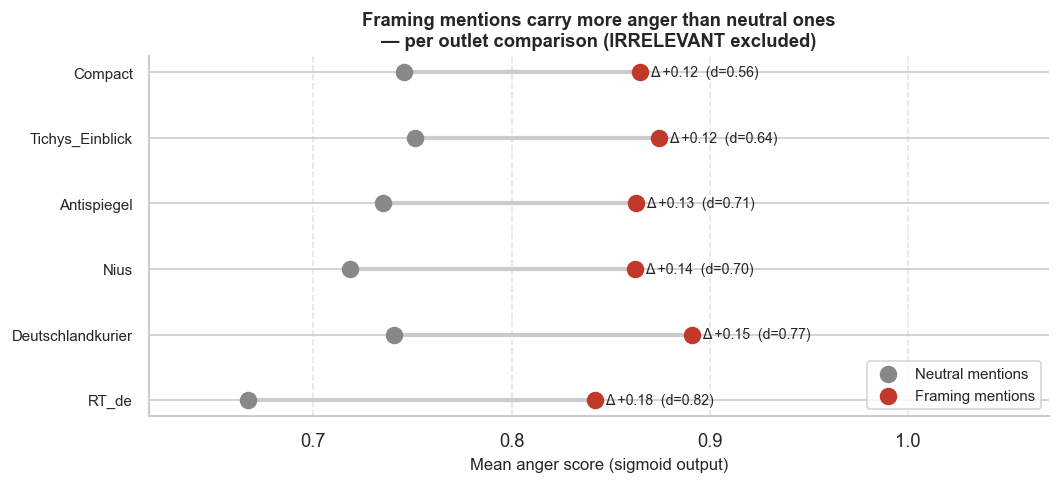

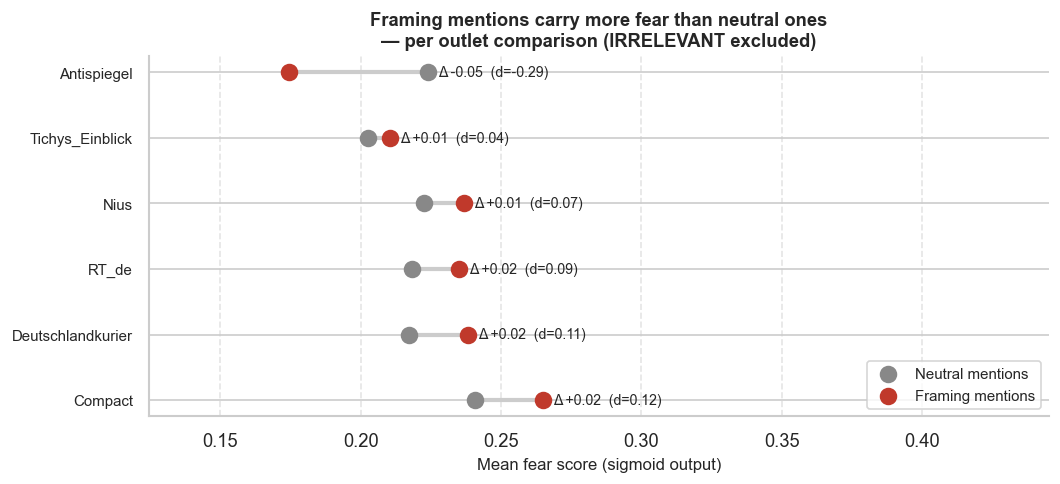

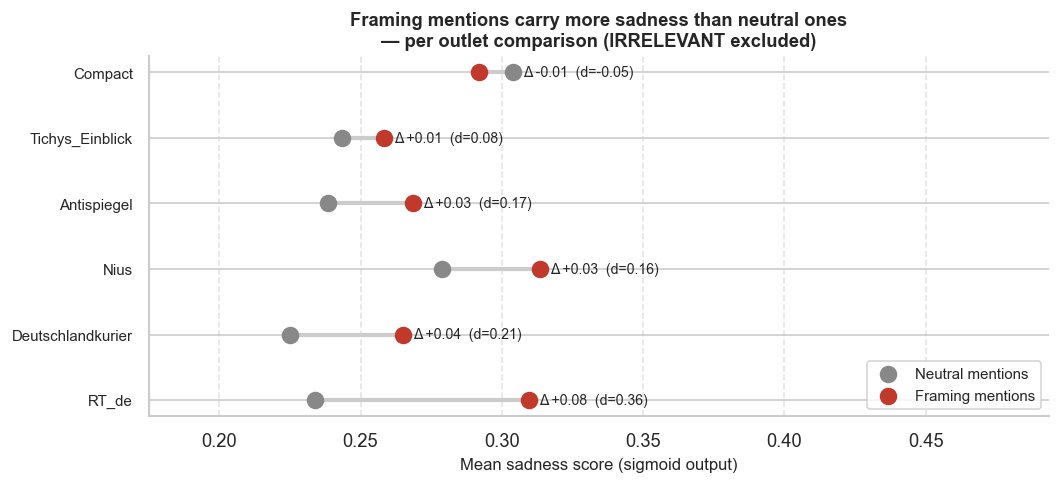

In [181]:
# ── Dumbbell chart: Neutral vs Framing mentions — mean emotion per outlet ────
#    Grey dot  = mean emotion for NEUTRAL hits
#    Red dot   = mean emotion for non-NEUTRAL (framing) hits
#    Line      = connects the two; Δ and Cohen's d annotated on the right

from scipy import stats as _stats

def _cohens_d(a, b):
    """Pooled-SD Cohen's d (returns NaN when pooled_sd == 0)."""
    n_a, n_b = len(a), len(b)
    if n_a < 2 or n_b < 2:
        return float("nan")
    pooled_var = ((n_a - 1) * a.var(ddof=1) + (n_b - 1) * b.var(ddof=1)) / (n_a + n_b - 2)
    pooled_sd  = pooled_var ** 0.5
    if pooled_sd == 0:
        return float("nan")
    return (b.mean() - a.mean()) / pooled_sd

for emo_col in ["emotion_anger", "emotion_fear", "emotion_sadness"]:
    emo_name = emo_col.replace("emotion_", "")

    rows = []
    for outlet, grp in df.groupby("source"):
        neutral  = grp.loc[grp["category"] == "NEUTRAL",  emo_col].dropna()
        framing  = grp.loc[grp["category"] != "NEUTRAL",  emo_col].dropna()
        if len(neutral) < 5 or len(framing) < 5:
            continue
        rows.append({
            "outlet":  outlet,
            "neutral": neutral.mean(),
            "framing": framing.mean(),
            "delta":   framing.mean() - neutral.mean(),
            "d":       _cohens_d(neutral, framing),
        })

    if not rows:
        print(f"[{emo_name}] not enough data — skipped")
        continue

    plot_df = (
        pd.DataFrame(rows)
        .sort_values("delta", ascending=False)
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(9, max(4, len(plot_df) * 0.7)))

    for i, row in plot_df.iterrows():
        ax.plot([row["neutral"], row["framing"]], [i, i],
                color="#cccccc", linewidth=2.5, zorder=1)
        ax.scatter(row["neutral"], i, color="#888888", s=90, zorder=2,
                   label="Neutral mentions"  if i == 0 else "")
        ax.scatter(row["framing"], i, color="#c0392b", s=90, zorder=2,
                   label="Framing mentions"  if i == 0 else "")

        sign  = "+" if row["delta"] >= 0 else ""
        d_str = f"(d={row['d']:.2f})" if not pd.isna(row["d"]) else ""
        ax.annotate(
            f"Δ {sign}{row['delta']:.2f}  {d_str}",
            xy=(max(row["neutral"], row["framing"]), i),
            xytext=(6, 0), textcoords="offset points",
            va="center", fontsize=8.5,
        )

    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df["outlet"], fontsize=9)
    ax.set_xlabel(f"Mean {emo_name} score (sigmoid output)", fontsize=10)
    ax.set_xlim(
        plot_df[["neutral", "framing"]].min().min() - 0.05,
        plot_df[["neutral", "framing"]].max().max() + 0.18,
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

    ax.set_title(
        f"Framing mentions carry more {emo_name} than neutral ones\n"
        f"— per outlet comparison (IRRELEVANT excluded)",
        fontsize=11, fontweight="bold",
    )
    ax.legend(loc="lower right", frameon=True, fontsize=9)

    plt.tight_layout()
    plt.show()


In [182]:
# summary_stats.to_csv(FIG_DIR / "../tables_emotion_summary_stats.csv")
# mean_by_outlet.to_csv(FIG_DIR / "../tables_mean_emotion_by_outlet.csv")
# outlet_summary.to_csv(FIG_DIR / "../tables_outlet_counts.csv", index=False)
# print("Wrote CSV tables to outputs/tables_*.csv")